# Advance Bank Term Deposit

## Introduction
This notebook provides a detailed analysis of customer behavior and insights into factors influencing term deposit subscription.

### Objective
Analyze customer demographics and campaign performance to understand factors influencing term deposit subscriptions.

## Load Dataset

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

sns.set_theme(style='whitegrid', palette='muted')

In [3]:
df = pd.read_csv("data.csv")

### Display the First Few Rows

In [4]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


### Dataset Overview

In [12]:
print("Shape:", df.shape)
df.info()

Shape: (41188, 21)
<class 'pandas.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  str    
 2   marital         41188 non-null  str    
 3   education       41188 non-null  str    
 4   default         41188 non-null  str    
 5   housing         41188 non-null  str    
 6   loan            41188 non-null  str    
 7   contact         41188 non-null  str    
 8   month           41188 non-null  str    
 9   day_of_week     41188 non-null  str    
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  str    
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 n

### Check for Missing Values and Duplicates

In [13]:
print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())


Missing Values:
age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

Duplicate Rows:
12


## Observation
The dataset appears complete and suitable for analysis. Any missing or duplicate records identified should be handled before further exploration.

## Customer Demographics Analysis

#### Age distribution

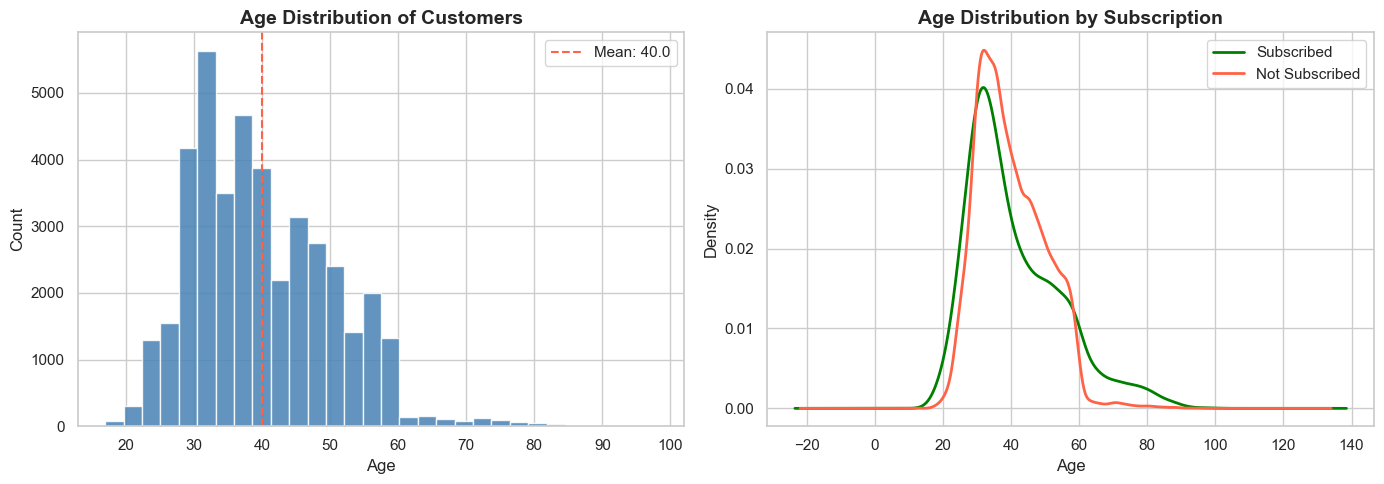

Age statistics:
       count   mean    std   min   25%   50%   75%   max
y                                                       
no   36548.0  39.91   9.90  17.0  32.0  38.0  47.0  95.0
yes   4640.0  40.91  13.84  17.0  31.0  37.0  50.0  98.0


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Overall age distribution
axes[0].hist(df['age'], bins=30, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_title('Age Distribution of Customers', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Count')
axes[0].axvline(df['age'].mean(), color='tomato', linestyle='--', label=f'Mean: {df["age"].mean():.1f}')
axes[0].legend()

# Age distribution by subscription
df[df['y']=='yes']['age'].plot(kind='kde', ax=axes[1], label='Subscribed', color='green', linewidth=2)
df[df['y']=='no']['age'].plot(kind='kde', ax=axes[1], label='Not Subscribed', color='tomato', linewidth=2)
axes[1].set_title('Age Distribution by Subscription', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Age')
axes[1].set_ylabel('Density')
axes[1].legend()

plt.tight_layout()
plt.show()

print('Age statistics:')
print(df.groupby('y')['age'].describe().round(2))

## Observation
Most customers belong to the working-age population, indicating that the campaign primarily targets economically active individuals.

#### Job distribution

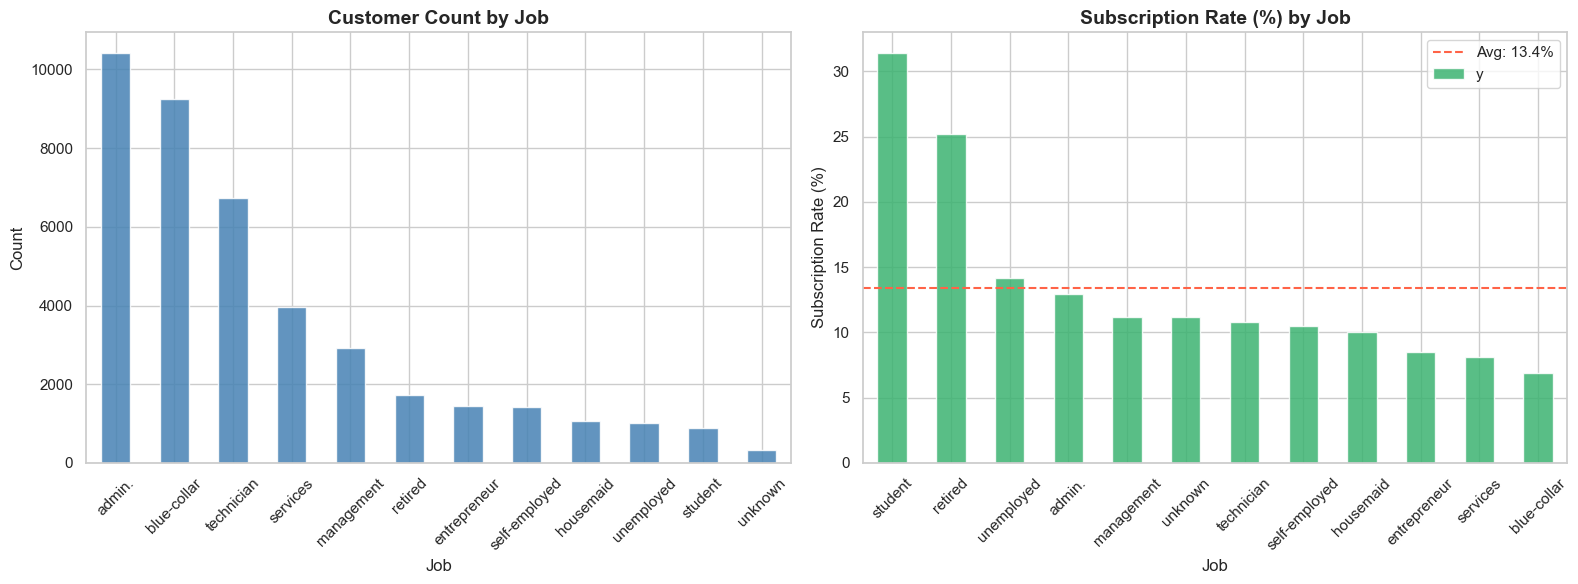

In [15]:
job_subscription = df.groupby('job')['y'].apply(lambda x: (x=='yes').mean()*100).sort_values(ascending=False)
job_counts = df['job'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Job count
job_counts.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_title('Customer Count by Job', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Job')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

# Subscription rate by job
job_subscription.plot(kind='bar', ax=axes[1], color='mediumseagreen', edgecolor='white', alpha=0.85)
axes[1].set_title('Subscription Rate (%) by Job', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Job')
axes[1].set_ylabel('Subscription Rate (%)')
axes[1].tick_params(axis='x', rotation=45)
axes[1].axhline(job_subscription.mean(), color='tomato', linestyle='--', label=f'Avg: {job_subscription.mean():.1f}%')
axes[1].legend()

plt.tight_layout()
plt.show()

#### Observation
Administrative, technician, and blue-collar occupations represent a significant portion of the customer base.

## Balance & Deposit Trends

#### Average balance by deposit subscription

y
no     220.844807
yes    553.191164
Name: duration, dtype: float64


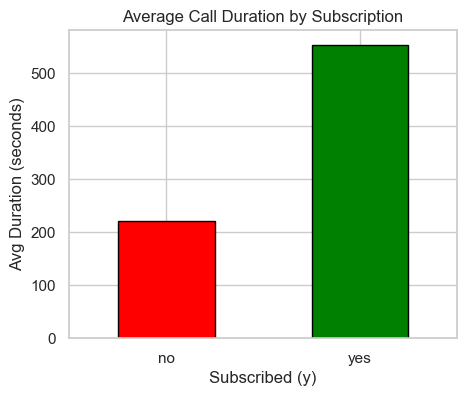

In [17]:
avg_duration = df.groupby('y')['duration'].mean()
print(avg_duration)

plt.figure(figsize=(5,4))
avg_duration.plot(kind='bar', color=['red','green'], edgecolor='black')
plt.title('Average Call Duration by Subscription')
plt.xlabel('Subscribed (y)')
plt.ylabel('Avg Duration (seconds)')
plt.xticks(rotation=0)
plt.show()

## Campaign Effectiveness

#### Contact method analysis

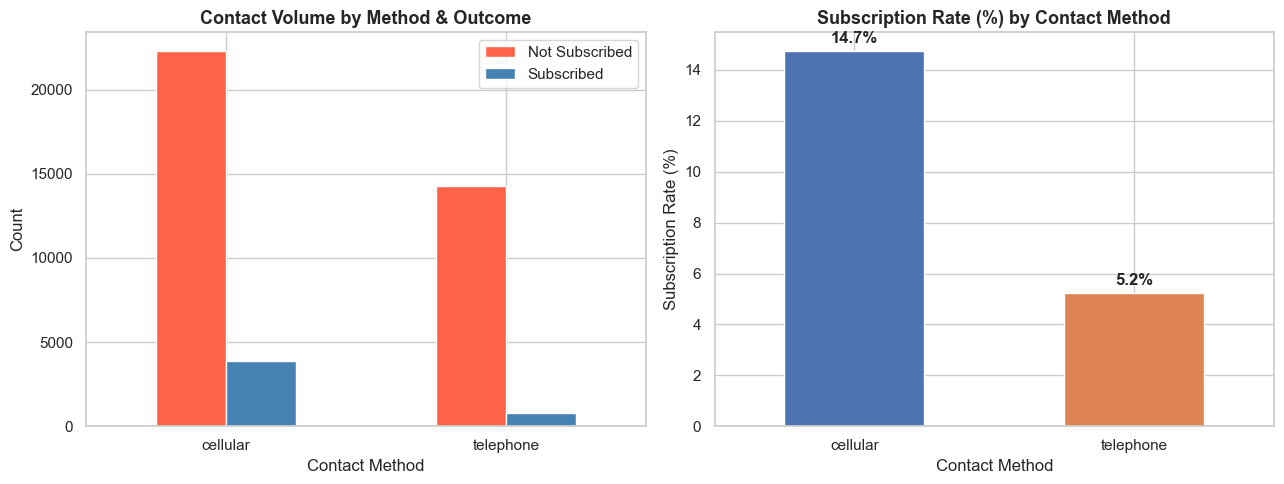

In [18]:
contact_sub = df.groupby('contact')['y'].apply(lambda x: (x=='yes').mean()*100)
contact_counts = df.groupby(['contact','y']).size().unstack(fill_value=0)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

contact_counts.plot(kind='bar', ax=axes[0], color=['tomato','steelblue'], edgecolor='white')
axes[0].set_title('Contact Volume by Method & Outcome', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Contact Method')
axes[0].set_ylabel('Count')
axes[0].legend(['Not Subscribed','Subscribed'])
axes[0].tick_params(axis='x', rotation=0)

contact_sub.plot(kind='bar', ax=axes[1], color=['#4C72B0','#DD8452'], edgecolor='white')
axes[1].set_title('Subscription Rate (%) by Contact Method', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Contact Method')
axes[1].set_ylabel('Subscription Rate (%)')
axes[1].tick_params(axis='x', rotation=0)
for i, v in enumerate(contact_sub):
    axes[1].text(i, v+0.3, f'{v:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

#### Number of contacts vs deposit subscription

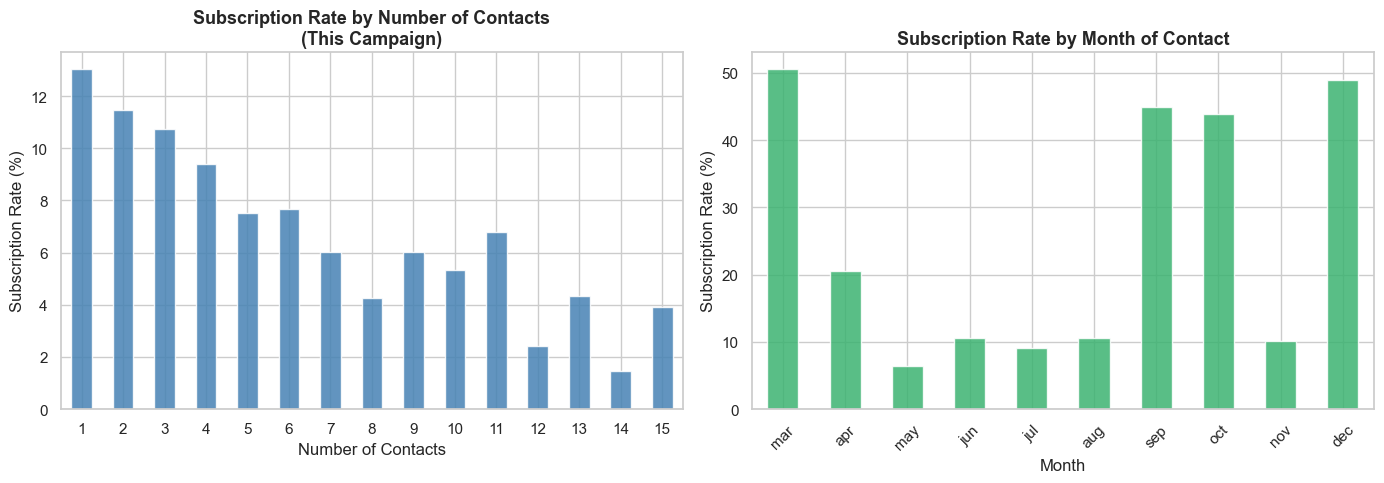

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Campaign contacts distribution
df_filtered = df[df['campaign'] <= 15]  # cap at 15 for readability
campaign_sub = df_filtered.groupby('campaign')['y'].apply(lambda x: (x=='yes').mean()*100)

campaign_sub.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_title('Subscription Rate by Number of Contacts\n(This Campaign)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Number of Contacts')
axes[0].set_ylabel('Subscription Rate (%)')
axes[0].tick_params(axis='x', rotation=0)

# Month of contact vs subscription rate
month_order = ['jan','feb','mar','apr','may','jun','jul','aug','sep','oct','nov','dec']
month_sub = df.groupby('month')['y'].apply(lambda x: (x=='yes').mean()*100).reindex(month_order).dropna()
month_sub.plot(kind='bar', ax=axes[1], color='mediumseagreen', edgecolor='white', alpha=0.85)
axes[1].set_title('Subscription Rate by Month of Contact', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Subscription Rate (%)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## Correlation Heatmap

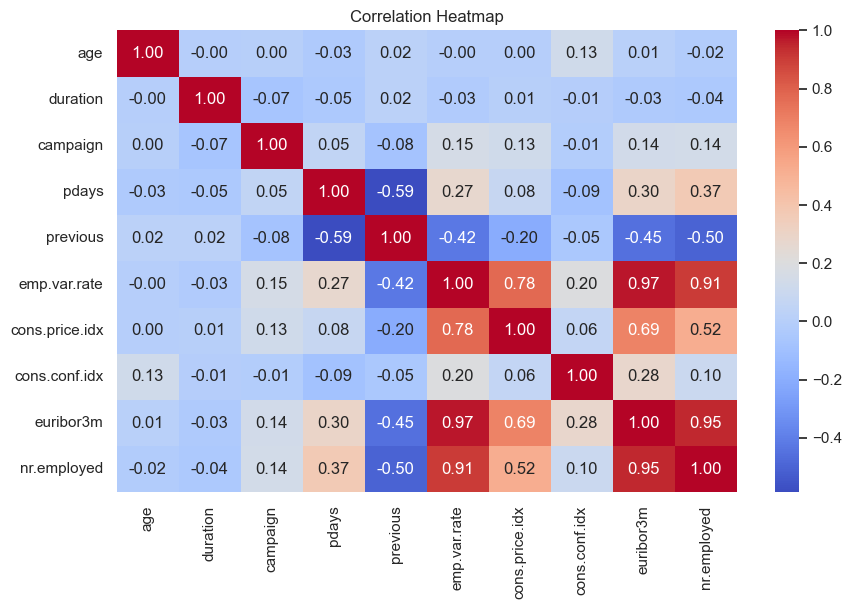

In [16]:
num_df = df.select_dtypes(include='number')

plt.figure(figsize=(10,6))
sns.heatmap(num_df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

## Predictive Modeling (Logistic Regression)

#### Encode categorical variables.

In [19]:
df_model = df.copy()

cat_cols = ['job','marital','education','default','housing','loan','contact','month','day_of_week','poutcome']
le = LabelEncoder()
for col in cat_cols:
    df_model[col] = le.fit_transform(df_model[col].astype(str))

df_model['y'] = (df_model['y'] == 'yes').astype(int)

feature_cols = ['age','job','marital','education','default','housing','loan',
                'contact','month','day_of_week','duration','campaign','pdays','previous','poutcome',
                'emp.var.rate','cons.price.idx','cons.conf.idx','euribor3m','nr.employed']

X = df_model[feature_cols]
y = df_model['y']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Train Logistic Regression
model = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
model.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:

#### Predictions

=== Model Performance ===
              precision    recall  f1-score   support

          No       0.99      0.85      0.91      7310
         Yes       0.43      0.90      0.59       928

    accuracy                           0.86      8238
   macro avg       0.71      0.88      0.75      8238
weighted avg       0.92      0.86      0.88      8238



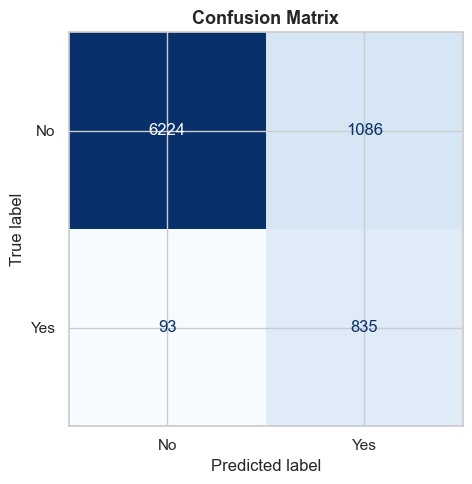

In [20]:
y_pred = model.predict(X_test_scaled)

print('=== Model Performance ===')
print(classification_report(y_test, y_pred, target_names=['No','Yes']))

# Confusion Matrix
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No','Yes'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Confusion Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

#### Feature importance

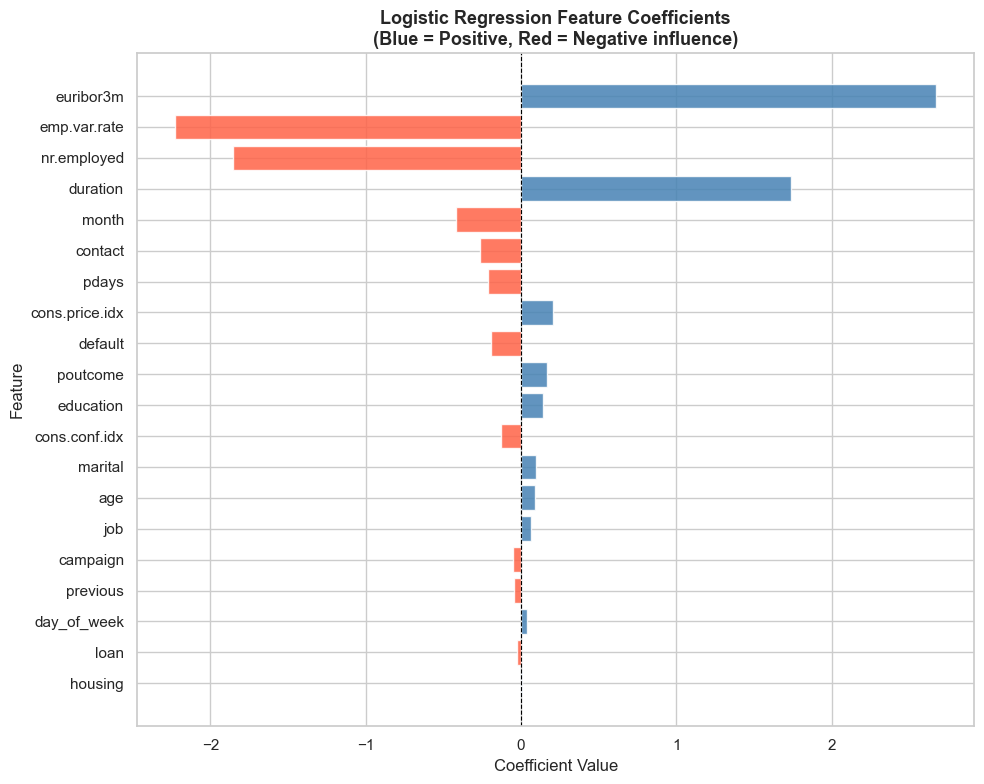


Top 5 features by importance:
     Feature  Coefficient
   euribor3m     2.672292
emp.var.rate    -2.225521
 nr.employed    -1.852402
    duration     1.737813
       month    -0.420155


In [21]:
coef_df = pd.DataFrame({'Feature': feature_cols, 'Coefficient': model.coef_[0]})
coef_df['Abs_Coefficient'] = coef_df['Coefficient'].abs()
coef_df = coef_df.sort_values('Abs_Coefficient', ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))
colors = ['tomato' if c < 0 else 'steelblue' for c in coef_df['Coefficient']]
ax.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors, edgecolor='white', alpha=0.85)
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title('Logistic Regression Feature Coefficients\n(Blue = Positive, Red = Negative influence)', 
             fontsize=13, fontweight='bold')
ax.set_xlabel('Coefficient Value')
ax.set_ylabel('Feature')
plt.tight_layout()
plt.show()

print('\nTop 5 features by importance:')
print(coef_df.nlargest(5, 'Abs_Coefficient')[['Feature','Coefficient']].to_string(index=False))

## Key Takeaways
- Certain age groups and job categories are more likely to subscribe.
- Higher balances correlate with higher subscription rates.
- Cellular contact is more effective than telephone.
- Campaign duration and number of contacts influence outcomes.
- Logistic regression shows which features are strongest predictors.